# Comparaison `best_small2` vs `best_small3` — 6 runs × 2 datasets de test

Deux configs candidates :
- **best_small2** : MegaDNA (bact) + NT2 (phage)
- **best_small3** : MegaDNA (bact) + NT2 (phage, Truncate) ⊕ MegaDNA (phage, BottomTruncate)

Procédure : pour chaque config, **6 entraînements indépendants** sur le train
set PredPhi, puis évaluation sur deux jeux de test :
- **test (PredPhi)** : `data/perphect-data/predphi/predphi_test_dataset.csv`
- **généralisation (all)** : `data/perphect-data/all/couples_df.csv`

On rapporte la **moyenne ± écart-type** sur les 6 runs.


In [1]:
%cd ..
!pwd

/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code
/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code


/home/nathan/anaconda3/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
import time
import copy
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    matthews_corrcoef, confusion_matrix,
)

# PyTorch >= 2.6 : torch.load() utilise weights_only=True par défaut, ce qui
# fait échouer le chargement des checkpoints MegaDNA (modèle complet picklé).
# On remet l'ancien comportement (safe puisqu'on charge nos propres poids).
_orig_torch_load = torch.load
def _torch_load_compat(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _orig_torch_load(*args, **kwargs)
torch.load = _torch_load_compat

from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput
from pbi_utils.config_parser import InputConfig
from main import (
    parse_config, reduce_dimensionality, make_dataset,
    train_nn_model,
    create_embeddings_bacteria, create_embeddings_phages,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

Device : cuda


## 1. Chargement des configs

In [3]:
configs = {
    "best_small2": parse_config(config_path="model_configs/best_small2.yaml"),
    "best_small3": parse_config(config_path="model_configs/best_small3.yaml"),
}
for name, c in configs.items():
    bact  = [m.name() for m in c.bacteria_embedding_models]
    phage = [m.name() for m in c.phages_embedding_models]
    print(f"{name}: bact={bact} | phage={phage}")

[INFO] Configuration loaded from model_configs/best_small2.yaml: Config(input_perphect=bacteria_df='data/perphect-data/predphi/bacteria_sequences.csv' phages_df='data/perphect-data/predphi/bacteriophages_sequences.csv' couples_df='data/perphect-data/predphi/predphi_train_dataset.csv', embeddings_dir=data/embeddings-pbip, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True do_test=False epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 training_noise_std=0.05 stratify_cv=True k_folds_cv=1 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='none' n_components_bacteria=None n_components_phages=None), phages_embedding_models=[NT2(merging_strategy=TruncateStrategy(), overlap=0, model_name='nucleotide-transformer-v2-250m-multi-species')], compute_phages_embeddings=[True], bacteria_embedding_models=[MegaDNA(merging_strategy=TruncateStrategy(),

## 2. Fonctions utilitaires

Même logique que `models_comparison.ipynb` :
1. `load_ds` charge le dataset (embeddings concaténés selon la config) pour des `input_paths` et un `embeddings_dir` donnés.
2. `train_fresh` instancie un classifieur neuf et l'entraîne sur un train set.
3. `evaluate` retourne un dict de métriques.

In [4]:
def load_ds(config, input_paths, embeddings_dir):
    """Charge un dataset (embeddings concaténés) pour la config donnée."""
    cfg = copy.deepcopy(config)
    cfg.input_perphect = input_paths
    output_manager = H5pyEmbeddingsManager(embeddings_dir)
    bact_df, phage_df, couples_df = PerphectDataInput(input_paths=input_paths).load()

    create_embeddings_bacteria(
        bacteria_models=cfg.bacteria_embedding_models,
        compute_bacteria_embeddings=cfg.compute_bacteria_embeddings,
        bacteria_df=bact_df, output_manager=output_manager,
    )
    create_embeddings_phages(
        phages_models=cfg.phages_embedding_models,
        compute_phages_embeddings=cfg.compute_phages_embeddings,
        phages_df=phage_df, output_manager=output_manager,
    )

    bact_names  = [m.name() for m in cfg.bacteria_embedding_models]
    phage_names = [m.name() for m in cfg.phages_embedding_models]
    ds = make_dataset(couples_df, bact_names, phage_names, output_manager, device)
    ds = reduce_dimensionality(
        ds, cfg.training_config.reduce_dimensionality, cfg.output_dir,
        cfg.training_config.n_components_bacteria,
        cfg.training_config.n_components_phages,
    )
    return ds


def train_fresh(config, train_ds):
    bact_size  = len(train_ds["bacterium_embedding"].iloc[0])
    phage_size = len(train_ds["phage_embedding"].iloc[0])
    model = config.classifier(bact_size, phage_size, **config.classifier_params).to(device)
    train_nn_model(train_ds, model, config.training_config, device=device, verbose=0)
    model.eval()
    return model


def evaluate(model, ds):
    preds, probs, labels = [], [], []
    model.eval()
    with torch.no_grad():
        for _, row in ds.iterrows():
            b = row["bacterium_embedding"].unsqueeze(0).to(device)
            p = row["phage_embedding"].unsqueeze(0).to(device)
            out = model(b, p)
            prob = torch.softmax(out, dim=1)[0]
            preds.append(int(prob.argmax().item()))
            probs.append(float(prob[1].item()))
            labels.append(int(row["interaction_type"]))
    preds, labels = np.array(preds), np.array(labels)
    return {
        "mcc":       matthews_corrcoef(labels, preds),
        "f1":        f1_score(labels, preds, zero_division=0),
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "confusion": confusion_matrix(labels, preds),
    }

## 3. Chargement des datasets

- **Train** : PredPhi train (embeddings dans `data/embeddings-pbip`)
- **Test PredPhi** : embeddings dans `data/embeddings-pbip`
- **Test all** : embeddings dans `data/embeddings`

Les embeddings nécessaires (notamment `MegaDNA-BottomTruncateStrategy` pour
`best_small3`) sont déjà cachés dans les deux dirs — aucune recomputation lourde.

In [5]:
input_train = InputConfig(
    bacteria_df="data/perphect-data/predphi/bacteria_sequences.csv",
    phages_df="data/perphect-data/predphi/bacteriophages_sequences.csv",
    couples_df="data/perphect-data/predphi/predphi_train_dataset.csv",
)
input_test_predphi = InputConfig(
    bacteria_df="data/perphect-data/predphi/bacteria_sequences.csv",
    phages_df="data/perphect-data/predphi/bacteriophages_sequences.csv",
    couples_df="data/perphect-data/predphi/predphi_test_dataset.csv",
)
input_test_all = InputConfig(
    bacteria_df="data/perphect-data/all/bacteria_df.csv",
    phages_df="data/perphect-data/all/phages_df.csv",
    couples_df="data/perphect-data/all/couples_df.csv",
)

In [6]:
datasets = {}
for name, cfg in configs.items():
    print(f"\n=== {name} ===")
    t0 = time.time()
    ds_tr  = load_ds(cfg, input_train,        embeddings_dir="data/embeddings-pbip")
    ds_te  = load_ds(cfg, input_test_predphi, embeddings_dir="data/embeddings-pbip")
    ds_all = load_ds(cfg, input_test_all,     embeddings_dir="data/embeddings")
    datasets[name] = {"train": ds_tr, "test_predphi": ds_te, "test_all": ds_all}
    print(f"  train={len(ds_tr)} | test_predphi={len(ds_te)} | test_all={len(ds_all)}  ({time.time()-t0:.1f}s)")
    print(f"  bact_size={len(ds_tr['bacterium_embedding'].iloc[0])}  phage_size={len(ds_tr['phage_embedding'].iloc[0])}")


=== best_small2 ===
[INFO] Embeddings will be stored or read from data/embeddings-pbip
[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_train_dataset.csv
[INFO] Reading csv files...
[INFO] Creating embeddings for 0 bacteria models...
[DEBUG] Skipping bacteria model MegaDNA-TruncateStrategy-concat-ov0 (use_cached_embeddings=True).
[INFO] Creating embeddings for 0 phages models...
[DEBUG] Skipping phage model NT2-TruncateStrategy-250M-ov0 (use_cached_embeddings=True).
[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 5702 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/5702 [00:00<?, ?it/s]

[DEBUG] Loading 5702 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/5702 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
[INFO] Embeddings will be stored or read from data/embeddings-pbip
[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_test_dataset.csv
[INFO] Reading csv files...
[INFO] Creating embeddings for 0 bacteria models...
[DEBUG] Skipping bacteria model MegaDNA-TruncateStrategy-concat-ov0 (use_cached_embeddings=True).
[INFO] Creating embeddings for 0 phages models...
[DEBUG] Skipping phage model NT2-TruncateStrategy-250M-ov0 (use_cached_embeddings=True).
[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 1236 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip


...

[DEBUG] Loading 7720 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/7720 [00:00<?, ?it/s]

[DEBUG] Loading 7720 embeddings for model MegaDNA-BottomTruncateStrategy-concat-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/7720 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 1732
  train=5702 | test_predphi=1236 | test_all=7720  (20.3s)
  bact_size=964  phage_size=1732


## 4. Boucle train + eval (6 runs × 2 configs × 2 test sets)

In [7]:
N_RUNS = 10
records = []

for name, cfg in configs.items():
    print(f"\n=== {name} ({N_RUNS} runs) ===")
    for run in range(N_RUNS):
        t0 = time.time()
        model = train_fresh(cfg, datasets[name]["train"])
        m_te  = evaluate(model, datasets[name]["test_predphi"])
        m_all = evaluate(model, datasets[name]["test_all"])
        elapsed = time.time() - t0
        for split, m in [("test_predphi", m_te), ("test_all", m_all)]:
            records.append({
                "config": name, "run": run, "split": split,
                **{k: v for k, v in m.items() if k != "confusion"},
            })
        print(f"  run {run+1}/{N_RUNS} ({elapsed:.1f}s) | "
              f"test MCC={m_te['mcc']:.3f} F1={m_te['f1']:.3f}  ||  "
              f"all  MCC={m_all['mcc']:.3f} F1={m_all['f1']:.3f}")

df_runs = pd.DataFrame(records)
df_runs.to_csv("analysis/best_small_comparison_runs.csv", index=False)
print(f"\n{len(df_runs)} mesures sauvegardées dans analysis/best_small_comparison_runs.csv")


=== best_small2 (10 runs) ===
  run 1/10 (9.0s) | test MCC=0.566 F1=0.774  ||  all  MCC=0.343 F1=0.587
  run 2/10 (8.6s) | test MCC=0.565 F1=0.778  ||  all  MCC=0.339 F1=0.583
  run 3/10 (9.4s) | test MCC=0.552 F1=0.772  ||  all  MCC=0.289 F1=0.561
  run 4/10 (9.4s) | test MCC=0.551 F1=0.768  ||  all  MCC=0.340 F1=0.586
  run 5/10 (9.4s) | test MCC=0.591 F1=0.795  ||  all  MCC=0.325 F1=0.575
  run 6/10 (9.3s) | test MCC=0.534 F1=0.758  ||  all  MCC=0.346 F1=0.589
  run 7/10 (9.3s) | test MCC=0.544 F1=0.761  ||  all  MCC=0.300 F1=0.566
  run 8/10 (9.2s) | test MCC=0.523 F1=0.749  ||  all  MCC=0.370 F1=0.599
  run 9/10 (9.4s) | test MCC=0.503 F1=0.736  ||  all  MCC=0.308 F1=0.570
  run 10/10 (9.4s) | test MCC=0.567 F1=0.779  ||  all  MCC=0.302 F1=0.567

=== best_small3 (10 runs) ===
  run 1/10 (9.8s) | test MCC=0.585 F1=0.797  ||  all  MCC=0.350 F1=0.586
  run 2/10 (9.2s) | test MCC=0.508 F1=0.749  ||  all  MCC=0.330 F1=0.580
  run 3/10 (9.1s) | test MCC=0.559 F1=0.787  ||  all  MCC=0.3

## 5. Agrégation — moyenne ± écart-type

In [8]:
metrics_cols = ["mcc", "f1", "accuracy", "precision", "recall"]

agg = (
    df_runs.groupby(["config", "split"])[metrics_cols]
           .agg(["mean", "std"])
           .round(4)
)
print(agg.to_string())
agg

                             mcc              f1         accuracy         precision          recall        
                            mean     std    mean     std     mean     std      mean     std    mean     std
config      split                                                                                          
best_small2 test_all      0.3261  0.0257  0.5786  0.0123   0.5884  0.0216    0.4309  0.0139  0.8813  0.0209
            test_predphi  0.5496  0.0251  0.7670  0.0168   0.7742  0.0130    0.7916  0.0072  0.7442  0.0279
best_small3 test_all      0.3255  0.0175  0.5749  0.0077   0.5608  0.0172    0.4169  0.0093  0.9268  0.0234
            test_predphi  0.5497  0.0289  0.7763  0.0187   0.7744  0.0141    0.7691  0.0087  0.7846  0.0382


mcc              f1         accuracy          \
                            mean     std    mean     std     mean     std   
config      split                                                           
best_small2 test_all      0.3261  0.0257  0.5786  0.0123   0.5884  0.0216   
            test_predphi  0.5496  0.0251  0.7670  0.0168   0.7742  0.0130   
best_small3 test_all      0.3255  0.0175  0.5749  0.0077   0.5608  0.0172   
            test_predphi  0.5497  0.0289  0.7763  0.0187   0.7744  0.0141   

                         precision          recall          
                              mean     std    mean     std  
config      split                                           
best_small2 test_all        0.4309  0.0139  0.8813  0.0209  
            test_predphi    0.7916  0.0072  0.7442  0.0279  
best_small3 test_all        0.4169  0.0093  0.9268  0.0234  
            test_predphi    0.7691  0.0087  0.7846  0.0382

## 6. Comparaison visuelle

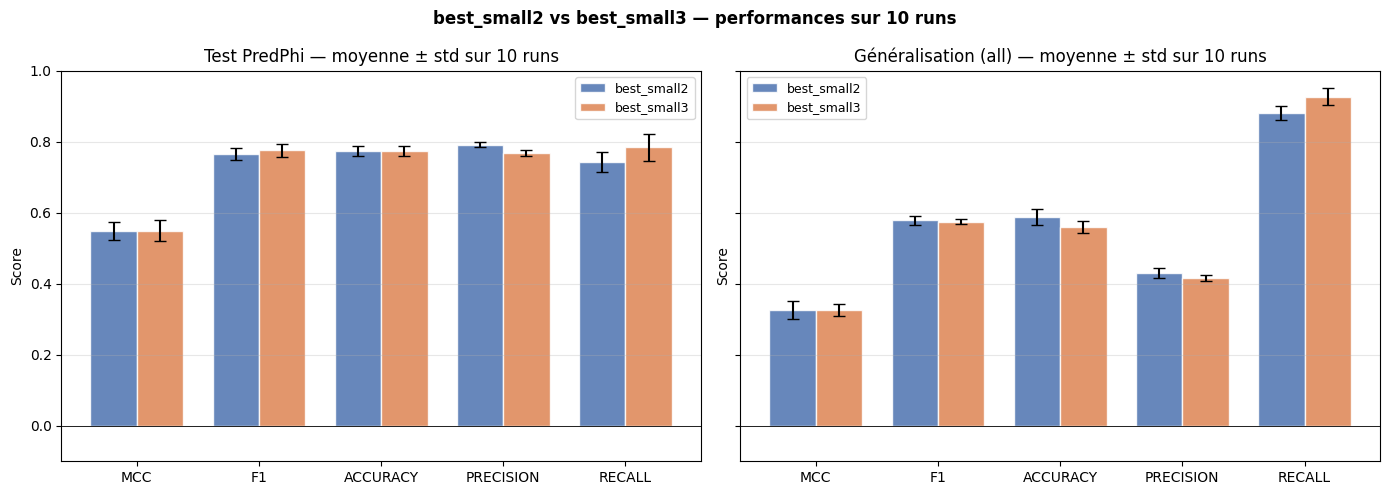

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

colors = {"best_small2": "#4C72B0", "best_small3": "#DD8452"}
metrics_to_plot = ["mcc", "f1", "accuracy", "precision", "recall"]
x = np.arange(len(metrics_to_plot))
w = 0.38

for ax, split, title in [
    (axes[0], "test_predphi", "Test PredPhi"),
    (axes[1], "test_all",     "Généralisation (all)"),
]:
    for i, cfg_name in enumerate(configs.keys()):
        sub = df_runs[(df_runs["config"] == cfg_name) & (df_runs["split"] == split)]
        means = [sub[m].mean() for m in metrics_to_plot]
        stds  = [sub[m].std()  for m in metrics_to_plot]
        ax.bar(x + (i - 0.5) * w, means, w, yerr=stds, label=cfg_name,
               color=colors[cfg_name], alpha=0.85, capsize=4, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in metrics_to_plot])
    ax.axhline(0, color="black", lw=0.6)
    ax.set_ylabel("Score")
    ax.set_ylim(-0.1, 1)
    ax.set_title(f"{title} — moyenne ± std sur {N_RUNS} runs")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle(f"best_small2 vs best_small3 — performances sur {N_RUNS} runs", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
# Vue compacte des deltas (best_small3 − best_small2) par métrique × split
delta_rows = []
for split in ["test_predphi", "test_all"]:
    for m in metrics_to_plot:
        a = df_runs[(df_runs["config"] == "best_small2") & (df_runs["split"] == split)][m]
        b = df_runs[(df_runs["config"] == "best_small3") & (df_runs["split"] == split)][m]
        delta_rows.append({
            "split":         split,
            "metric":        m,
            "small2_mean":   a.mean(),
            "small3_mean":   b.mean(),
            "delta (3 - 2)": b.mean() - a.mean(),
        })
df_delta = pd.DataFrame(delta_rows)
print(df_delta.round(4).to_string(index=False))

       split    metric  small2_mean  small3_mean  delta (3 - 2)
test_predphi       mcc       0.5496       0.5497         0.0001
test_predphi        f1       0.7670       0.7763         0.0093
test_predphi  accuracy       0.7742       0.7744         0.0002
test_predphi precision       0.7916       0.7691        -0.0226
test_predphi    recall       0.7442       0.7846         0.0405
    test_all       mcc       0.3261       0.3255        -0.0005
    test_all        f1       0.5786       0.5749        -0.0036
    test_all  accuracy       0.5884       0.5608        -0.0276
    test_all precision       0.4309       0.4169        -0.0140
    test_all    recall       0.8813       0.9268         0.0455
